# 02 — Build the 2-D dataset

This notebook turns the raw BreastDCEDL NIfTI volumes into the PNG dataset that
every experiment in this project trains on, centralised and federated alike. It
is the only place images are created. Nothing downstream ever re-crops, re-scales
or re-normalises: the federated setup notebook hardlinks these exact files, so the
bytes a hospital trains on are the same inodes written here.

Run this one first. Notebooks 03 and 06 both fail without it.

The whole pipeline is written out below rather than imported, so you can read what
happens to a voxel between the scanner and the model without opening another file.

**What comes out**

| | |
|---|---|
| 16,378 PNGs | `dataset/multi_subtype_80mm/images/<pid>/slice_NNN.png` |
| 2,063 patients | 1,527 train / 268 val / 268 test |
| one CSV per split | `train.csv`, `val.csv`, `test.csv` |
| the full table | `metadata.csv`, one row per image, 27 columns |
| the exact parameters used | `config.json` |

**The four rules that define this dataset**

| step | rule | why |
|---|---|---|
| slice selection | 8 spread across the lesion, trimming 15% off each end | 38 slices per patient was mostly near-duplicates, and it let one patient contribute 150 gradient samples against another's 8 |
| crop | 80 mm physical window, then resized to 224 px | fixing the crop in pixels would make magnification itself identify the cohort |
| normalisation | min-max over the whole volume | per-slice normalisation destroys the enhancement kinetics, which is the biological signal |
| channels | pre / early post / late post contrast, fused as RGB | one image carries the time course |

## Configuration

Everything this notebook needs is in the next cell. Nothing below it hard-codes a
path or a number. Read the comments before running: two of these paths must
already exist on disk, and the notebook cannot create them.

In [17]:
from pathlib import Path

# --------------------------------------------------------------------------- #
# PATHS — the first two must already exist, the rest are created by this notebook
# --------------------------------------------------------------------------- #

# Repository root. The notebook lives in notebooks/, so the parent is the root.
REPO_ROOT = Path.cwd().parent

# INPUT, must exist. The raw Zenodo download, never written to.
# Expect: BreastDCEDL_metadata_min_crop.csv plus one folder per cohort.
# Obtain it from https://zenodo.org/records/18114231 (MinCrop v4). It is far too
# large for version control, so it is not in the repository.
RAW_DIR = REPO_ROOT / "raw_dataset_BreastDCEDL"

# INPUT, must exist. The authors' harmonised metadata: one row per patient,
# carrying the labels, the official train/test/val split, the voxel spacing and
# the DUKE bounding boxes. No label is ever derived in code, so a label here can
# never disagree with the published one.
METADATA_CSV = RAW_DIR / "BreastDCEDL_metadata_min_crop.csv"

# INPUT, must exist. One folder per cohort of the MinCrop release.
# Inside each: dce/ (or crop_min_dce/ for DUKE) with the NIfTI volumes, and
# mask/ with the voxel-level tumour masks. DUKE ships no mask, only a box.
COHORT_DIRS = {
    "spy2": RAW_DIR / "BreastDCEDL_ISPY2_min_crop",
    "spy1": RAW_DIR / "BreastDCEDL_ISPY1_min_crop",
    "duke": RAW_DIR / "BreastDCEDL_DUKE_min_crop",
}

# OUTPUT, created by this notebook. The generated 2-D dataset.
# The folder name is pinned rather than derived from the pipeline and task,
# because the federated layer looks for exactly this name. Rename it and
# notebook 06 rebuilds a dataset it then cannot find.
DATASET_NAME = "multi_subtype_80mm"
OUT_DIR = REPO_ROOT / "dataset" / DATASET_NAME

# Where the images land: one subfolder per patient, so a patient can be moved,
# hardlinked or dropped as a unit. The federated partitioner relies on that.
IMAGES_DIR = OUT_DIR / "images"

# --------------------------------------------------------------------------- #
# THE TASK
# --------------------------------------------------------------------------- #

# Three molecular subtypes, read straight from the HR_HER2_STATUS column.
# The class order fixes the integer labels: 0, 1, 2 in this order, and every
# confusion matrix and per-class metric in the project reads them this way.
TASK_COLUMN = "HR_HER2_STATUS"
CLASS_NAMES = ("HRposHER2neg", "TripleNeg", "HER2pos")

# TASK_COLUMN, CLASS_NAMES = "HER2", ("HER2neg", "HER2pos")   # binary HER2, the authors' target
# TASK_COLUMN, CLASS_NAMES = "HR", ("HRneg", "HRpos")         # binary hormone receptor
# TASK_COLUMN, CLASS_NAMES = "pCR", ("no_pCR", "pCR")         # response; DUKE has it for only 298 of 916

# Which cohorts to pool. All three is what the reported experiments used, and it
# is what makes the federated hospitals genuinely non-IID in notebook 06.
COHORTS = ("spy2", "spy1", "duke")
# COHORTS = ("spy2",)                  # I-SPY2 alone, 982 patients
# COHORTS = ("duke",)                  # DUKE alone, 914 patients after the n_xy filter
# COHORTS = ("spy2", "spy1")           # the two I-SPY cohorts, no DUKE

# --------------------------------------------------------------------------- #
# PREPROCESSING CONSTANTS — these define the dataset
# --------------------------------------------------------------------------- #

N_SLICES = 8              # slices kept per patient
TRIM_FRACTION = 0.15      # fraction of the lesion discarded at each end before sampling
CROP_MM = 80.0            # physical crop window, millimetres
SAVE_SIZE = 224           # output image side, pixels. 80 mm / 224 px = 0.357 mm per pixel
MIN_TUMOR_PX = 10         # a slice with fewer tumour pixels than this is not a tumour slice
NORMALIZATION = "minmax"  # whole-volume min-max
# NORMALIZATION = "chanclip"   # per-channel q0.98 upper clip. The authors' own later
#                              # benchmark found this best for binary HER2. Measured
#                              # here on 3-class subtype it LOST: 0.5830 against 0.6078.

# The MinCrop volumes are already cropped in z to the tumour range plus this many
# slices of margin at each end. It is the authors' `slice_padding`, verified
# against the released data, and it is how the DUKE z-extent is recovered.
Z_MARGIN = 2

# --------------------------------------------------------------------------- #
# RUN CONTROL
# --------------------------------------------------------------------------- #

# Worker processes for the per-patient loop. On macOS the pool dies from a
# notebook, because spawn re-imports a parent module that does not exist here;
# the code below falls back to serial automatically. Same output, slower.
WORKERS = 8
# WORKERS = 1              # force serial, easier to debug a failing patient

DRY_RUN_FIRST = True       # print the plan and the counts before writing anything

print(f"repository   {REPO_ROOT}")
print(f"raw input    {RAW_DIR}          exists: {RAW_DIR.is_dir()}")
print(f"metadata     {METADATA_CSV.name}   exists: {METADATA_CSV.is_file()}")
print(f"output       {OUT_DIR}")
print(f"task         {TASK_COLUMN} -> {', '.join(CLASS_NAMES)}")
print(f"cohorts      {', '.join(COHORTS)}")

repository   /Users/daniel/Developer/tese/federated-breast-mri-subtyping
raw input    /Users/daniel/Developer/tese/federated-breast-mri-subtyping/raw_dataset_BreastDCEDL          exists: True
metadata     BreastDCEDL_metadata_min_crop.csv   exists: True
output       /Users/daniel/Developer/tese/federated-breast-mri-subtyping/dataset/multi_subtype_80mm
task         HR_HER2_STATUS -> HRposHER2neg, TripleNeg, HER2pos
cohorts      spy2, spy1, duke


## Imports

Everything the pipeline needs. `nibabel` reads the NIfTI volumes and `PIL` writes
the PNGs. Nothing here imports from `src/`, on purpose: this notebook is meant to
be readable on its own.

In [18]:
import csv
import json
from collections import Counter
from concurrent.futures import ProcessPoolExecutor
from dataclasses import asdict, dataclass

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

# Where each cohort keeps its DCE volumes and its masks. DUKE names its folder
# differently and ships no mask at all, which is the one real asymmetry in this
# pipeline and is handled explicitly further down.
DCE_SUBDIR = {"spy2": "dce", "spy1": "dce", "duke": "crop_min_dce"}
MASK_SUBDIR = {"spy2": "mask", "spy1": "mask"}      # DUKE has none

# The metadata encodes the official split as an integer in the `test` column.
SPLIT_MAP = {0: "train", 1: "test", 2: "val"}

print("ready")

ready


## Which patients go in

The first real step. This reads the metadata, keeps the patients that have a
usable label, and attaches the authors' official split rather than inventing a
new one. Using their split is what keeps any number here comparable with the
published ones.

Two patients get dropped here, and it is worth knowing why. DUKE ships an
expert-drawn bounding box instead of a voxel mask, and those box coordinates
index a 256x256 frame. Two DUKE patients were scanned at a different matrix size,
so the box does not map onto the MinCrop volume. Rather than guess at a rescaling,
they are removed.

In [19]:
def patient_table(metadata_csv=METADATA_CSV, cohorts=COHORTS,
                  task_column=TASK_COLUMN, class_names=CLASS_NAMES):
    """One row per patient that this build will process."""
    df = pd.read_csv(metadata_csv)
    df = df[df.dataset.isin(cohorts)].copy()

    if len(class_names) > 2:
        # Multi-class: keep only the rows whose label is one of ours, and map the
        # string to an integer using the order in CLASS_NAMES.
        df = df[df[task_column].isin(class_names)].copy()
        df["label"] = df[task_column].map({c: i for i, c in enumerate(class_names)})
        df["label_name"] = df[task_column]
    else:
        # Binary: the column is already 0/1, but it can be missing.
        before = len(df)
        df = df[df[task_column].notna()].copy()
        if before - len(df):
            print(f"[note] {before - len(df)} patients dropped: no {task_column}")
        df["label"] = df[task_column].astype(int)
        df["label_name"] = df.label.map(dict(enumerate(class_names)))

    # The authors' split, not a new one.
    df = df[df.test.isin(SPLIT_MAP)].copy()
    df["split"] = df.test.map(SPLIT_MAP)

    # The DUKE box only maps onto a 256x256 frame. See the markdown above.
    before = len(df)
    df = df[~((df.dataset == "duke") & (df.n_xy != 256))].copy()
    if before - len(df):
        print(f"[note] {before - len(df)} DUKE patients dropped: n_xy != 256, "
              f"the metadata box does not map onto the MinCrop volume")

    return df.reset_index(drop=True)


patients = patient_table()
print(f"\n{len(patients)} patients\n")
print(pd.crosstab(patients.dataset, [patients.split, patients.label_name]).to_string())

[note] 2 DUKE patients dropped: n_xy != 256, the metadata box does not map onto the MinCrop volume

2063 patients

split         test                          train                            val                       
label_name HER2pos HRposHER2neg TripleNeg HER2pos HRposHER2neg TripleNeg HER2pos HRposHER2neg TripleNeg
dataset                                                                                                
duke            24           82        30     114          426       102      23           84        29
spy1            10           15         8      32           42        27      12           12         9
spy2            19           40        40     198          305       281      25           36        38


## Rule 1 — which slices to keep

The old behaviour kept every slice that contained tumour: 38 per patient on
average, up to 150, and a fifth of them carrying fewer than 100 tumour pixels.
That hurts twice. The per-patient mean that produces the final prediction gets
diluted by near-empty slices, and a patient with 150 slices contributes 150
gradient samples against another patient's 8.

Two deliberate choices in the function below. The trim is proportional rather
than absolute, so a tumour spanning 60 slices loses 9 at each end while one
spanning 8 loses 1. An absolute rule would erase half of a small tumour. And the
sampling spreads across what remains instead of taking the N central slices,
because slices 1 to 2 mm apart are practically the same image.

A patient with fewer than 8 slices keeps all of them. Better five images than a
lost patient, and `n_slices_tumor` in the CSV records the original count so those
cases can be filtered later without reprocessing.

In [20]:
def select_slices(z_indices, n=N_SLICES, trim=TRIM_FRACTION):
    """Trim the extremes of the lesion, then sample `n` evenly spaced slices."""
    total = len(z_indices)
    if total == 0:
        return z_indices
    cut = int(np.floor(total * trim))
    # Only trim if enough is left afterwards, otherwise keep the whole lesion.
    core = z_indices[cut:total - cut] if total - 2 * cut >= max(n, 3) else z_indices
    if len(core) <= n:
        return core
    positions = np.linspace(0, len(core) - 1, n)
    return core[np.unique(np.round(positions).astype(int))]


# The alternative rule, which is what the dataset authors do: four consecutive
# slices centred on the middle of the mask. Asymmetric on purpose (idx-2 to
# idx+1), and the exclusive upper bound drops the last slice of a thin mask.
# Swap it in by renaming it over select_slices.
#
# def select_slices_reference(z_indices):
#     f, l = int(z_indices[0]), int(z_indices[-1])
#     mid = (f + l) // 2
#     chosen = np.arange(max(mid - 2, f), min(mid + 2, l))
#     if chosen.size == 0:
#         chosen = np.array([z_indices[len(z_indices) // 2]])
#     return chosen


# A quick sanity check on the rule, with no data involved.
for span in (6, 8, 20, 60):
    zs = np.arange(100, 100 + span)
    print(f"lesion spanning {span:3d} slices -> keeps {len(select_slices(zs)):2d}: "
          f"{select_slices(zs).tolist()}")

lesion spanning   6 slices -> keeps  6: [100, 101, 102, 103, 104, 105]
lesion spanning   8 slices -> keeps  8: [100, 101, 102, 103, 104, 105, 106, 107]
lesion spanning  20 slices -> keeps  8: [103, 105, 107, 109, 110, 112, 114, 116]
lesion spanning  60 slices -> keeps  8: [109, 115, 121, 127, 132, 138, 144, 150]


## Rule 2 — the crop window

This is the deviation that took the most working out, so the reasoning is worth
stating in full.

A crop expressed as a margin around the tumour box makes the lesion fill the
frame identically in every patient, and by doing that it erases tumour size.
Size is worth macro-AUC 0.58 to 0.68 on its own here, and it ranks as the most
important predictor in the authors' own feature-importance analysis. An 80 mm
frame keeps it: a 60 mm tumour occupies three times what a 20 mm one does, as in
reality.

The window is fixed in millimetres and not in pixels because `xy_spacing` ranges
from 0.31 to 1.41 mm per pixel across patients. After resizing to 224 every image
sits at the same 0.357 mm per pixel. Without that, the degree of magnification
would itself identify the cohort, and DUKE tumours have a median of 29 mm against
61 mm in I-SPY2.

Why 80 mm and not another number: it is the smallest window containing the whole
tumour for the median patient of all three cohorts, plus about 7 mm of
peritumoral tissue per side, which is the margin the peritumoral literature
reports as useful. It fully contains the lesion in 81% of patients.

The honest caveat belongs here too. On the same 99 I-SPY2 test patients this
preprocessing scored 0.5837 against 0.6201 for the older pipeline. That
difference is inside the 0.067 noise floor, so the verdict is no difference
detected, but it is certainly not the improvement that was expected. What it did
buy is a validation-to-test gap of +0.015 against +0.073.

In [21]:
def crop_window(row0, row1, col0, col1, xy_spacing, crop_mm=CROP_MM):
    """A square window of `crop_mm` MILLIMETRES centred on the lesion.

    Returns ((y0, y1, x0, x1), side_in_pixels). The window may fall outside the
    image and the caller pads with zeros. Padding beats shrinking: shrinking
    would change the scale only for peripheral tumours, and constant scale is the
    whole point of doing this in millimetres.
    """
    side = max(int(round(crop_mm / xy_spacing)), 8)
    cy, cx = (row0 + row1) // 2, (col0 + col1) // 2
    y0, x0 = cy - side // 2, cx - side // 2
    return (y0, y0 + side, x0, x0 + side), side


# The authors' rule instead: a fixed 224 px square, centred the same way. It
# gives every patient the same number of pixels and a different number of
# millimetres, which is exactly the trade this pipeline reverses.
#
# def crop_window_reference(row0, row1, col0, col1, crop_px=224):
#     cy, cx = (row0 + row1) // 2, (col0 + col1) // 2
#     y0, x0 = cy - crop_px // 2, cx - crop_px // 2
#     return (y0, y0 + crop_px, x0, x0 + crop_px), crop_px


for spacing in (0.31, 0.70, 1.41):
    (_, _, _, _), side = crop_window(100, 140, 100, 150, spacing)
    print(f"spacing {spacing:.2f} mm/px -> {side:3d} px crop -> resized to "
          f"{SAVE_SIZE} px = {spacing * side / SAVE_SIZE:.3f} mm/px")

spacing 0.31 mm/px -> 258 px crop -> resized to 224 px = 0.357 mm/px
spacing 0.70 mm/px -> 114 px crop -> resized to 224 px = 0.356 mm/px
spacing 1.41 mm/px ->  57 px crop -> resized to 224 px = 0.359 mm/px


## Rule 3 — normalisation

Min-max over the whole 4-D volume, meaning all three phases and all slices
together. That preserves the intensity relationship between slices of one patient
and between phases, which is the enhancement kinetics and therefore the actual
biological signal. Per-slice normalisation destroys it, because an almost-empty
slice ends up as bright as one with an intense lesion.

The alternative below, per-channel upper clipping, is the winner of the authors'
own later benchmark on binary HER2 where it scored 0.744 against 0.700 for global
min-max. It was measured here on the 3-class subtype task with two seeds and it
lost, 0.5830 against 0.6078. That is inside the noise floor, so the honest reading
is that their result does not transfer rather than that it is wrong. It is kept
available and it is not the default.

In [22]:
def normalize_volume(volume):
    """Min-max over the whole 4-D volume. Input and output are (3, Z, Y, X)."""
    lo, hi = float(np.nanmin(volume)), float(np.nanmax(volume))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(volume, dtype=np.float32)
    return np.clip((volume - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)


def normalize_channel_clip(volume, q=0.98):
    """Clip each phase's upper tail at its own quantile, then scale."""
    out = np.empty_like(volume, dtype=np.float32)
    for c in range(volume.shape[0]):
        channel = volume[c]
        hi = float(np.nanquantile(channel, q))
        lo = float(np.nanmin(channel))
        if not np.isfinite(hi) or not np.isfinite(lo) or hi <= lo:
            out[c] = 0.0
            continue
        out[c] = np.clip((channel - lo) / (hi - lo), 0.0, 1.0)
    return out


# The authors' rule: min-max of ONE slice, jointly over the three channels.
# Applied per slice after cropping rather than to the volume up front.
#
# def normalize_slice_reference(slice_3ch):
#     lo, hi = float(np.nanmin(slice_3ch)), float(np.nanmax(slice_3ch))
#     if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
#         return np.zeros_like(slice_3ch, dtype=np.float32)
#     return np.clip((slice_3ch - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)


NORMALIZERS = {"minmax": normalize_volume, "chanclip": normalize_channel_clip}
print(f"using {NORMALIZATION}: {NORMALIZERS[NORMALIZATION].__name__}")

using minmax: normalize_volume


## Finding the lesion

I-SPY1 and I-SPY2 ship a voxel-level 3-D mask. DUKE does not, it ships an
expert-drawn bounding box, which the dataset paper states in section 2.3. The
`ROI` container below carries whichever exists, so everything after this point
treats the three cohorts identically.

That asymmetry was checked rather than assumed. On I-SPY2, where both a mask and a
box are available, the box matches the mask exactly for 767 of 767 patients whose
original scan was already 256x256, and that covers 914 of the 916 DUKE patients.

One subtlety on the DUKE z extent. It does not come from the `mask_start` and
`mask_end` columns, because those index the original volume and MinCrop is already
cropped in z. It comes from the construction rule, verified against the release:
the MinCrop volume is exactly the tumour range plus two slices of margin at each
end, so the tumour occupies z in [2, nz-3].

In [23]:
@dataclass
class ROI:
    """Where the lesion is, from a mask or from a box."""
    zs: np.ndarray       # slice indices containing tumour
    row0: int
    row1: int
    col0: int
    col1: int
    source: str          # "mask" (I-SPY) or "bbox" (DUKE)
    mask: np.ndarray | None = None


def roi_from_mask(mask, min_px=MIN_TUMOR_PX):
    """Exact ROI from the 3-D binary mask, centred on the slice with most tumour.

    Centring on the largest-area slice rather than on the 3-D union is what makes
    this match the DUKE annotation, which is by definition a box drawn on the
    plane with the largest tumour area. The two centres differ by 2.3 mm at the
    median and up to 25.6 mm in the tail.
    """
    areas = mask.reshape(mask.shape[0], -1).sum(1)
    zs = np.where(areas >= min_px)[0]
    if zs.size == 0:
        return None
    plane = mask[int(np.argmax(areas))]
    ys, xs = np.nonzero(plane)
    return ROI(zs=zs, row0=int(ys.min()), row1=int(ys.max()) + 1,
               col0=int(xs.min()), col1=int(xs.max()) + 1, source="mask", mask=mask)


def roi_from_box(row, n_z, z_margin=Z_MARGIN):
    """ROI from the metadata box (DUKE)."""
    if int(row["n_xy"]) != 256:
        return None                       # the box does not map, see above
    z0, z1 = z_margin, n_z - z_margin
    if z1 <= z0:                          # a volume too thin for the margin rule
        z0, z1 = 0, n_z
    r0, r1, c0, c1 = (int(row["sraw"]), int(row["eraw"]),
                      int(row["scol"]), int(row["ecol"]))
    if not (0 <= r0 < r1 <= 256 and 0 <= c0 < c1 <= 256):
        return None
    return ROI(zs=np.arange(z0, z1), row0=r0, row1=r1, col0=c0, col1=c1,
               source="bbox")


print("ROI readers defined for both annotation types")

ROI readers defined for both annotation types


## Reading the volumes, and cropping with padding

Two small helpers. The first locates the three DCE phases for one patient. When a
requested acquisition index is missing it falls back to the last available one
rather than to an arbitrary file, which is what the authors specify for DUKE, and
the index actually used is written into the CSV so no substitution is invisible.

The second crops and zero-pads whatever falls outside the frame. That is the
padding the millimetre window needs.

In [24]:
def phase_paths(dce_dir, pid, cohort, wanted):
    """Files for the three phases, and the acquisition indices actually used."""
    available = {}
    for f in dce_dir.glob(f"{pid}_{cohort}*_dce_aqc_*.nii.gz"):
        available[int(f.name.split("aqc_")[1].split(".")[0])] = f
    if not available:
        raise FileNotFoundError(f"{pid}: no DCE files")
    paths, used = [], []
    for i in wanted:
        i = int(i) if int(i) in available else max(available)
        paths.append(available[i])
        used.append(i)
    return paths, used


def crop_pad(img, box):
    """Crop to `box` = (y0, y1, x0, x1), zero-padding whatever falls outside."""
    y0, y1, x0, x1 = box
    h, w = img.shape[-2:]
    out = np.zeros(img.shape[:-2] + (y1 - y0, x1 - x0), dtype=img.dtype)
    sy0, sx0, sy1, sx1 = max(y0, 0), max(x0, 0), min(y1, h), min(x1, w)
    if sy1 > sy0 and sx1 > sx0:
        out[..., sy0 - y0:sy1 - y0, sx0 - x0:sx1 - x0] = img[..., sy0:sy1, sx0:sx1]
    return out


print("volume readers defined")

volume readers defined


## What one row of the output CSV holds

27 columns per image. Most of them exist so that a later question can be answered
without reprocessing anything: which acquisition was actually used, how big the
tumour was in this particular frame, how many slices the lesion originally
spanned, what the resampling factor was.

Two conventions matter. `tumor_pixels`, `tumor_area_mm2` and `tumor_fraction` are
set to -1 where only a bounding box exists, never imputed, so a DUKE row can never
be mistaken for a measured one. And `filename` is `<pid>/slice_NNN.png`, keeping
the patient in the path, which is what lets the federated partitioner move a
patient as a unit.

In [25]:
@dataclass
class Record:
    """One row of the output CSV — one per generated image."""
    filename: str
    pid: str
    cohort: str
    split: str
    label: int
    label_name: str
    slice_index: int         # z position in the volume
    slice_order: int         # 0..7, position within the 8 kept
    z_rel: float             # where in the lesion, 0 at the first slice, 1 at the last
    n_slices_tumor: int      # how many slices the lesion originally spanned
    phase_pre: int           # the acquisition index actually used, per phase
    phase_early: int
    phase_late: int
    roi_source: str          # "mask" or "bbox"
    tumor_pixels: int        # -1 where only a box exists, never imputed
    tumor_area_mm2: float
    tumor_fraction: float
    bbox_x: int              # tumour box within the SAVED frame
    bbox_y: int
    bbox_w: int
    bbox_h: int
    xy_spacing: float        # original, mm per pixel
    slice_thick: float
    crop_px: int             # the 80 mm window in original pixels
    img_size: int            # always SAVE_SIZE
    mm_per_px: float         # after resizing, should be constant across the dataset
    tum_vol: float


FIELDS = list(Record.__dataclass_fields__)
print(f"{len(FIELDS)} columns per image")

27 columns per image


## Processing one patient

This is where the four rules meet. Read in order: load the three phases, locate
the lesion, normalise the volume, choose the slices, compute the crop window, then
write one PNG per chosen slice and one record per PNG.

The function returns `(records, error)` rather than raising, because one
unreadable patient out of two thousand should not abort a two-hour build. The
errors are collected and printed as a summary at the end, and they also go into
`config.json`.

It takes a single packed argument so it can be handed straight to
`ProcessPoolExecutor.map`.

In [26]:
def process_patient(args):
    """One patient. Returns (records, error_string_or_None)."""
    row, opts, out_dir = args
    pid, cohort = row["pid"], row["dataset"]
    root = opts["cohort_dirs"][cohort]

    # ---- load the three DCE phases ------------------------------------- #
    try:
        paths, phases = phase_paths(root / DCE_SUBDIR[cohort], pid, cohort,
                                    [row["pre"], row["post_early"], row["post_late"]])
        vols = [np.nan_to_num(np.asarray(nib.load(str(p)).dataobj, dtype=np.float32),
                              nan=0.0, posinf=0.0, neginf=0.0) for p in paths]
    except Exception as exc:
        return [], f"read: {exc}"

    if len({v.shape for v in vols}) != 1:
        return [], "phases have different shapes"
    vol = np.stack(vols)                                   # (3, Z, Y, X)
    n_z = vol.shape[1]

    # ---- locate the lesion --------------------------------------------- #
    if cohort in MASK_SUBDIR:
        mf = next((root / MASK_SUBDIR[cohort]).glob(f"{pid}_*_mask.nii.gz"), None)
        if mf is None:
            return [], "no mask"
        mask = np.asarray(nib.load(str(mf)).dataobj) > 0
        if mask.shape != vol.shape[1:]:
            return [], f"mask {mask.shape} != dce {vol.shape[1:]}"
        roi = roi_from_mask(mask, opts["min_tumor_px"])
    else:
        roi = roi_from_box(row, n_z)
    if roi is None:
        return [], "no usable ROI"

    # ---- normalise, at the volume level -------------------------------- #
    vol = NORMALIZERS[opts["normalization"]](vol)

    # ---- choose the slices --------------------------------------------- #
    chosen = select_slices(roi.zs, opts["n_slices"], opts["trim_fraction"])
    if len(chosen) == 0:
        return [], "no slice survived selection"

    # ---- the crop window ------------------------------------------------ #
    spacing = float(row["xy_spacing"])
    if not np.isfinite(spacing) or spacing <= 0:
        return [], "invalid xy_spacing"
    box, side = crop_window(roi.row0, roi.row1, roi.col0, roi.col1,
                            spacing, opts["crop_mm"])

    pdir = out_dir / "images" / pid
    pdir.mkdir(parents=True, exist_ok=True)
    S = opts["save_size"]
    scale = S / side
    z0, z1 = int(roi.zs[0]), int(roi.zs[-1])
    span = max(z1 - z0, 1)
    records = []

    for order, z in enumerate(chosen):
        z = int(z)
        plane = crop_pad(vol[:, z], box)
        img = (np.clip(plane, 0, 1) * 255).astype(np.uint8).transpose(1, 2, 0)
        if img.shape[0] != S:
            img = np.asarray(Image.fromarray(img).resize((S, S), Image.LANCZOS))
        name = f"slice_{z:03d}.png"
        Image.fromarray(img, "RGB").save(pdir / name, optimize=True)

        # Tumour measurements INSIDE THE SAVED FRAME, so they describe what the
        # model actually sees. Where there is no mask they stay at -1.
        if roi.mask is not None:
            mz = crop_pad(roi.mask[z], box)
            px = int(mz.sum())
            ys, xs = np.nonzero(mz)
            if ys.size:
                bx, by = int(xs.min() * scale), int(ys.min() * scale)
                bw = int((xs.max() - xs.min() + 1) * scale)
                bh = int((ys.max() - ys.min() + 1) * scale)
            else:
                bx = by = bw = bh = 0
            area, frac = px * spacing * spacing, float(mz.mean())
        else:
            px, area, frac = -1, -1.0, -1.0
            bx = int((roi.col0 - box[2]) * scale)
            by = int((roi.row0 - box[0]) * scale)
            bw = int((roi.col1 - roi.col0) * scale)
            bh = int((roi.row1 - roi.row0) * scale)

        records.append(asdict(Record(
            filename=f"{pid}/{name}", pid=pid, cohort=cohort, split=row["split"],
            label=int(row["label"]), label_name=str(row["label_name"]),
            slice_index=z, slice_order=order, z_rel=round((z - z0) / span, 4),
            n_slices_tumor=len(roi.zs),
            phase_pre=phases[0], phase_early=phases[1], phase_late=phases[2],
            roi_source=roi.source, tumor_pixels=px,
            tumor_area_mm2=round(float(area), 2), tumor_fraction=round(frac, 6),
            bbox_x=bx, bbox_y=by, bbox_w=bw, bbox_h=bh,
            xy_spacing=round(spacing, 4),
            slice_thick=round(float(row["slice_thick"]), 3),
            crop_px=side, img_size=S, mm_per_px=round(spacing * side / S, 5),
            tum_vol=float(row["tum_vol"]) if np.isfinite(row["tum_vol"]) else -1.0)))
    return records, None


print("per-patient pipeline defined")

per-patient pipeline defined


## The dry run

Prints the plan and the patient counts without writing a single file. Always look
at this before spending the disk and the two hours. The crosstab is the thing to
check: if a class or a split is missing here, it will be missing from the dataset.

In [27]:
OPTS = dict(cohort_dirs=COHORT_DIRS, n_slices=N_SLICES,
            trim_fraction=TRIM_FRACTION, crop_mm=CROP_MM, save_size=SAVE_SIZE,
            normalization=NORMALIZATION, min_tumor_px=MIN_TUMOR_PX)

if DRY_RUN_FIRST:
    print(f"BUILD  {TASK_COLUMN}  ->  {OUT_DIR}")
    print(f"  cohorts : {', '.join(COHORTS)}")
    print(f"  patients: {len(patients)}")
    print(f"  slices  : {N_SLICES} spread, trimming {TRIM_FRACTION:.0%} each end")
    print(f"  crop    : {CROP_MM:.0f} mm physical -> {SAVE_SIZE} px")
    print(f"  norm    : {NORMALIZATION}, whole volume")
    print()
    print(pd.crosstab(patients.dataset,
                      [patients.split, patients.label_name]).to_string())
    print("\nnothing written yet")

BUILD  HR_HER2_STATUS  ->  /Users/daniel/Developer/tese/federated-breast-mri-subtyping/dataset/multi_subtype_80mm
  cohorts : spy2, spy1, duke
  patients: 2063
  slices  : 8 spread, trimming 15% each end
  crop    : 80 mm physical -> 224 px
  norm    : minmax, whole volume

split         test                          train                            val                       
label_name HER2pos HRposHER2neg TripleNeg HER2pos HRposHER2neg TripleNeg HER2pos HRposHER2neg TripleNeg
dataset                                                                                                
duke            24           82        30     114          426       102      23           84        29
spy1            10           15         8      32           42        27      12           12         9
spy2            19           40        40     198          305       281      25           36        38

nothing written yet


## Build

Two hours for the full three-cohort build, less if the process pool works. The
pool is tried first and the code falls back to serial if it cannot start, which is
what happens on macOS from a notebook: worker processes there use `spawn`, which
re-imports the parent module, and a notebook has no importable parent. The output
is identical either way.

This cell refuses to overwrite an existing build. Delete the folder to rebuild.

In [28]:
def run_tasks(tasks, workers):
    """Process every patient, in parallel where that works and serially where not."""
    records, errors = [], {}

    def absorb(i, result):
        recs, err = result
        if err:
            errors[tasks[i - 1][0]["pid"]] = err
        records.extend(recs)
        if i % 200 == 0 or i == len(tasks):
            print(f"  {i}/{len(tasks)} patients · {len(records)} images · "
                  f"{len(errors)} errors", flush=True)

    if workers and workers > 1:
        try:
            with ProcessPoolExecutor(max_workers=workers) as ex:
                for i, res in enumerate(ex.map(process_patient, tasks, chunksize=4), 1):
                    absorb(i, res)
            return records, errors
        except Exception as exc:
            print(f"  [note] parallel pool unavailable ({type(exc).__name__}); "
                  f"falling back to serial. Same output, slower.")
            records, errors = [], {}

    for i, t in enumerate(tasks, 1):
        absorb(i, process_patient(t))
    return records, errors


if (OUT_DIR / "metadata.csv").is_file():
    print(f"{OUT_DIR.name}: already built — delete the folder to rebuild")
    meta = pd.read_csv(OUT_DIR / "metadata.csv", low_memory=False)
    errors = {}
else:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    tasks = [(r, OPTS, OUT_DIR) for _, r in patients.iterrows()]
    records, errors = run_tasks(tasks, WORKERS)

    if errors:
        print(f"\n{len(errors)} patients failed:")
        for reason, n in Counter(errors.values()).most_common():
            print(f"  {n:4d}  {reason}")

    meta = pd.DataFrame(records)

print(f"\n{len(meta):,} images from {meta.pid.nunique():,} patients")

Process SpawnProcess-2:
Process SpawnProcess-1:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/concurrent/futures/process.py", line 252, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'process_patient' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
  File "/Library/Frameworks/Python.

  [note] parallel pool unavailable (BrokenProcessPool); falling back to serial. Same output, slower.
  200/2063 patients · 1592 images · 0 errors
  400/2063 patients · 3175 images · 0 errors
  600/2063 patients · 4749 images · 0 errors
  800/2063 patients · 6331 images · 0 errors
  1000/2063 patients · 7912 images · 0 errors
  1200/2063 patients · 9489 images · 0 errors
  1400/2063 patients · 11089 images · 0 errors
  1600/2063 patients · 12687 images · 0 errors
  1800/2063 patients · 14275 images · 0 errors
  2000/2063 patients · 15874 images · 0 errors
  2063/2063 patients · 16378 images · 0 errors

16,378 images from 2,063 patients


## Write the CSVs

One table for everything and one per split. The per-split files are what the
training notebook reads, and splitting them here means the training loop never has
to filter, which in turn means it cannot filter wrongly.

In [29]:
if not (OUT_DIR / "metadata.csv").is_file():
    meta[FIELDS].to_csv(OUT_DIR / "metadata.csv", index=False,
                        quoting=csv.QUOTE_MINIMAL)
    for split, sub in meta.groupby("split"):
        sub[FIELDS].to_csv(OUT_DIR / f"{split}.csv", index=False)

    # The exact parameters, stored beside the data. Any question about how this
    # dataset was made is answerable from this file alone.
    (OUT_DIR / "config.json").write_text(json.dumps({
        "n_slices": N_SLICES, "trim_fraction": TRIM_FRACTION, "crop_mm": CROP_MM,
        "save_size": SAVE_SIZE, "normalization": NORMALIZATION,
        "min_tumor_px": MIN_TUMOR_PX, "task_column": TASK_COLUMN,
        "class_names": list(CLASS_NAMES), "cohorts": list(COHORTS),
        "n_patients": int(meta.pid.nunique()), "n_images": len(meta),
        "errors": errors}, indent=2))

for f in sorted(OUT_DIR.glob("*.csv")):
    print(f"  {f.name:<16} {len(pd.read_csv(f)):>7,} rows")
print(f"  {'config.json':<16} {(OUT_DIR / 'config.json').stat().st_size:>7,} bytes")

  metadata.csv      16,378 rows
  test.csv           2,115 rows
  train.csv         12,131 rows
  val.csv            2,132 rows
  config.json          358 bytes


## Verification

These checks decide whether the dataset can be trusted, and the cell raises if any
of them fails. The first is the one that matters most: no patient may appear in
two splits. Splitting by slice instead of by patient is the classic leak in this
kind of work, and it inflates every number without ever looking wrong.

In [31]:
def verify(meta, out_dir):
    """Checks that must pass before the dataset can be trusted. Raises if not."""
    print("VERIFICATION")
    failures = []

    by_split = meta.groupby("split").pid.unique()
    for a in by_split.index:
        for b in by_split.index:
            if a < b:
                shared = set(by_split[a]) & set(by_split[b])
                ok = not shared
                print(f"  [{'ok' if ok else 'FAIL'}] no patient in both {a} and {b}")
                if not ok:
                    failures.append(f"leak {a}/{b}")

    checks = [
        ("one label per patient", (meta.groupby("pid").label.nunique() == 1).all()),
        ("no duplicate filenames", not meta.filename.duplicated().any()),
        ("all files on disk",
         not [f for f in meta.filename if not (out_dir / "images" / f).is_file()]),
        ("single image size", meta.img_size.nunique() == 1),
        ("labels in range",
         set(meta.label.unique()) <= set(range(meta.label.max() + 1))),
    ]
    for name, ok in checks:
        print(f"  [{'ok' if ok else 'FAIL'}] {name}")
        if not ok:
            failures.append(name)

    if failures:
        raise RuntimeError(f"VERIFICATION FAILED: {failures}")
    print("  all checks passed")


verify(meta, OUT_DIR)

VERIFICATION
  [ok] no patient in both test and train
  [ok] no patient in both test and val
  [ok] no patient in both train and val
  [ok] one label per patient
  [ok] no duplicate filenames
  [ok] all files on disk
  [ok] single image size
  [ok] labels in range
  all checks passed


## What came out

The counts the rest of the project quotes. The trivial baseline on the test split
is the number that makes accuracy readable at all: predicting the majority class
for everyone gets you 0.5112 here, so an accuracy of 0.53 is barely above doing
nothing.

In [32]:
p = meta.drop_duplicates("pid")

print(f"{len(meta):,} images · {p.pid.nunique():,} patients · "
      f"{len(meta) / p.pid.nunique():.2f} slices per patient\n")
print(pd.crosstab(p.split, p.label_name, margins=True).to_string())
print()
print(pd.crosstab(p.cohort, p.label_name, margins=True).to_string())

base = p[p.split == "test"].label_name.value_counts()
print(f"\ntrivial baseline accuracy on test: {base.max()}/{base.sum()} = "
      f"{base.max() / base.sum():.4f}")

# The scale check. If the physical crop worked, mm_per_px is the same everywhere.
print(f"\nmm per pixel after resizing: {meta.mm_per_px.min():.3f} to "
      f"{meta.mm_per_px.max():.3f}  (constant scale is the point of the mm crop)")

16,378 images · 2,063 patients · 7.94 slices per patient

label_name  HER2pos  HRposHER2neg  TripleNeg   All
split                                             
test             53           137         78   268
train           344           773        410  1527
val              60           132         76   268
All             457          1042        564  2063

label_name  HER2pos  HRposHER2neg  TripleNeg   All
cohort                                            
duke            161           592        161   914
spy1             54            69         44   167
spy2            242           381        359   982
All             457          1042        564  2063

trivial baseline accuracy on test: 137/268 = 0.5112

mm per pixel after resizing: 0.355 to 0.360  (constant scale is the point of the mm crop)


## Sample images

Random patients, not the first rows of the file. The dataset is ordered by patient,
so taking the head would show one cohort and sometimes several slices of the same
person.

Each column is a different patient. This is worth looking at properly, because the
cohort differences are visible by eye: DUKE tumours are noticeably smaller in the
frame, which is exactly the shortcut the source probe picks up.

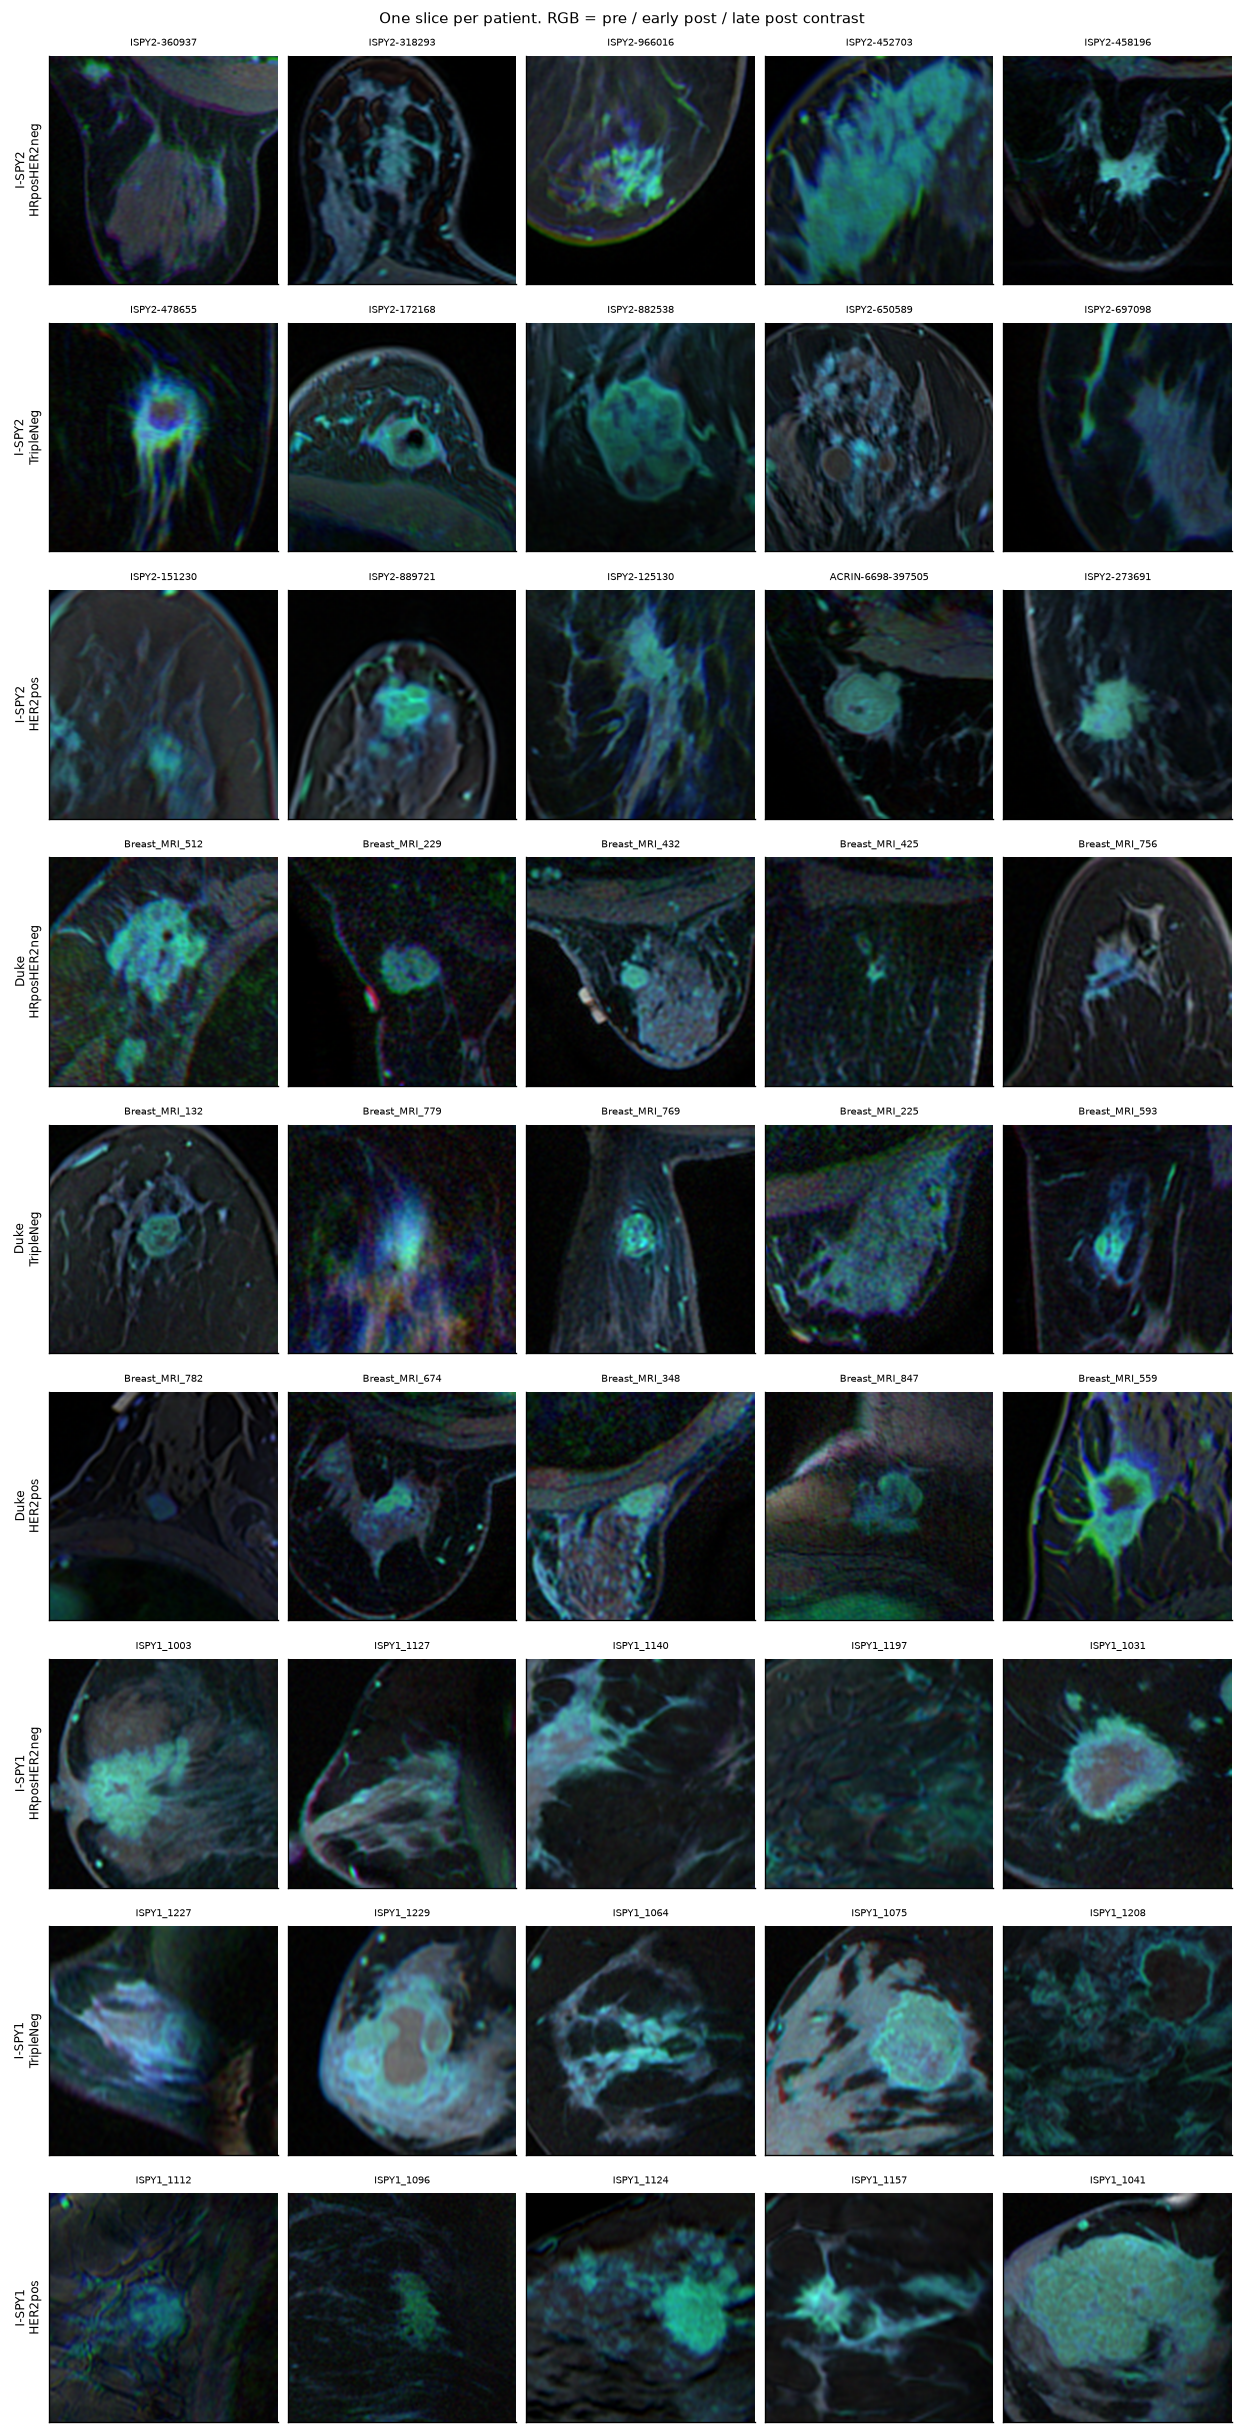

In [33]:
SAMPLE_SEED = 42       # change to draw a different set of patients
N_EXAMPLES = 5         # patients shown per cohort and class

COHORT_LABEL = {"spy2": "I-SPY2", "duke": "Duke", "spy1": "I-SPY1"}
cohorts = [c for c in ["spy2", "duke", "spy1"] if c in set(meta.cohort)]
classes = [c for c in CLASS_NAMES if c in set(meta.label_name)]
rng = np.random.default_rng(SAMPLE_SEED)

rows_grid = [(co, cl) for co in cohorts for cl in classes]
fig, axes = plt.subplots(len(rows_grid), N_EXAMPLES,
                         figsize=(2.05 * N_EXAMPLES, 2.25 * len(rows_grid)),
                         layout="constrained")
axes = np.atleast_2d(axes)

for r, (co, cl) in enumerate(rows_grid):
    sub = meta[(meta.cohort == co) & (meta.label_name == cl)]
    # Sample PATIENTS, then take one slice each. Sampling rows would happily
    # return five slices of the same tumour and show nothing about the cohort.
    pids = sub.pid.unique()
    chosen = rng.choice(pids, size=min(N_EXAMPLES, len(pids)), replace=False)

    for c in range(N_EXAMPLES):
        ax = axes[r, c]
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if c >= len(chosen):
            ax.axis("off")
            continue
        pid = chosen[c]
        prow = sub[sub.pid == pid].iloc[len(sub[sub.pid == pid]) // 2]
        ax.imshow(Image.open(IMAGES_DIR / prow.filename))
        ax.set_title(f"{pid}", fontsize=6)
        if c == 0:
            ax.set_ylabel(f"{COHORT_LABEL.get(co, co)}\n{cl}", fontsize=7)

fig.suptitle("One slice per patient. RGB = pre / early post / late post contrast",
             fontsize=9)
plt.show()

## What this notebook produced

Everything below is written by the cells above, and nothing else in the project
writes into this folder.

| path | what it is |
|---|---|
| `dataset/multi_subtype_80mm/images/<pid>/slice_NNN.png` | one PNG per kept slice, 224x224, RGB = pre / early / late contrast |
| `dataset/multi_subtype_80mm/metadata.csv` | one row per image, 27 columns, every measurement made during the build |
| `dataset/multi_subtype_80mm/train.csv` | the training split, 1,527 patients |
| `dataset/multi_subtype_80mm/val.csv` | the validation split, 268 patients |
| `dataset/multi_subtype_80mm/test.csv` | the held-out test split, 268 patients |
| `dataset/multi_subtype_80mm/config.json` | the exact parameters used, plus any patient that failed and why |

**Where this goes next**

Notebook 03 trains the centralised baseline directly on these CSVs. Notebook 06
hardlinks these same PNGs into per-hospital folders for the federated runs, so no
image is ever copied or regenerated, and the federated arm provably trains on the
same pixels as the centralised one.

**The one caveat to carry forward.** A source probe trained on this pooled dataset,
identical pipeline with the cohort as the label, reaches macro-AUC 0.9978. The
images identify their cohort almost perfectly. The cohorts also differ in class
prior, DUKE is 64.6% HRposHER2neg against I-SPY2's 38.8%, so "small tumour, so
DUKE, so HRposHER2neg" is available to the model as a shortcut with no biology in
it. That is a real effect and it must be reported beside any result measured here.
It is not a reason to avoid pooling, because pooled data is what makes the
federated hospitals genuinely non-IID in notebook 06.